In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

In [2]:
saheart_df=pd.read_csv("SAheart.csv")
saheart_df

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,Si
1,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,Si
2,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,No
3,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,Si
4,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,Si
...,...,...,...,...,...,...,...,...,...,...
457,214,0.40,5.98,31.72,Absent,64,28.45,0.00,58,No
458,182,4.20,4.41,32.10,Absent,52,28.61,18.72,52,Si
459,108,3.00,1.59,15.23,Absent,40,20.09,26.64,55,No
460,118,5.40,11.61,30.79,Absent,64,27.35,23.97,40,No


In [3]:
x=saheart_df.shape
print(f"No. of records: {x[0]}")

No. of records: 462


In [4]:
saheart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sbp        462 non-null    int64  
 1   tobacco    462 non-null    float64
 2   ldl        462 non-null    float64
 3   adiposity  462 non-null    float64
 4   famhist    462 non-null    object 
 5   typea      462 non-null    int64  
 6   obesity    462 non-null    float64
 7   alcohol    462 non-null    float64
 8   age        462 non-null    int64  
 9   chd        462 non-null    object 
dtypes: float64(5), int64(3), object(2)
memory usage: 36.2+ KB


In [5]:
counts=pd.crosstab(saheart_df['famhist'], saheart_df['chd'])
print(counts)

chd       No  Si
famhist         
Absent   206  64
Present   96  96


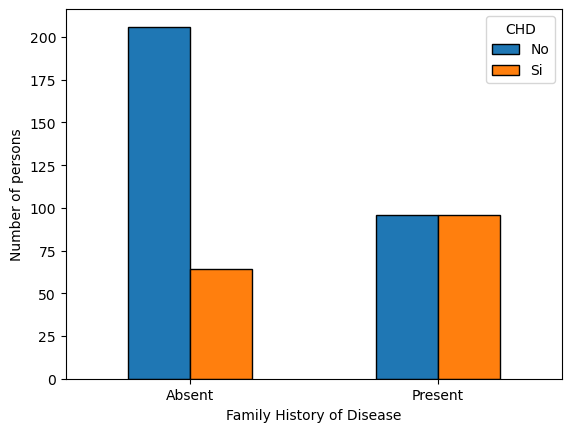

In [6]:
counts.plot(kind='bar', edgecolor='black', linewidth=1)
plt.xlabel('Family History of Disease')
plt.ylabel('Number of persons')
plt.xticks(rotation=0)
plt.legend(title='CHD')
plt.show()

In [7]:
saheart_df[['age', 'sbp']].corr()

,age,sbp
age,1.000000,0.388771
sbp,0.388771,1.000000


<Axes: >

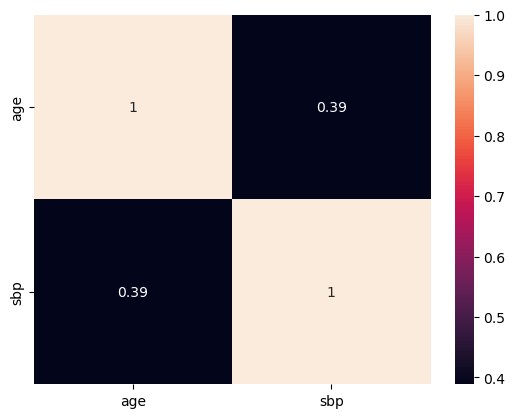

In [8]:
sn.heatmap(saheart_df[['age', 'sbp']].corr(), annot=True)

In [27]:
tobacco_no_chd=saheart_df[saheart_df['chd']=='No']['tobacco']
tobacco_chd=saheart_df[saheart_df['chd']=='Si']['tobacco']
saheart_df.groupby('chd')['tobacco'].describe()


,count,mean,std,min,25%,50%,75%,max
chd,,,,,,,,
No,302.0,2.634735,3.612095,0.0,0.0,1.035,4.2,20.0
Si,160.0,5.524875,5.565143,0.0,1.5,4.130,8.2,31.2


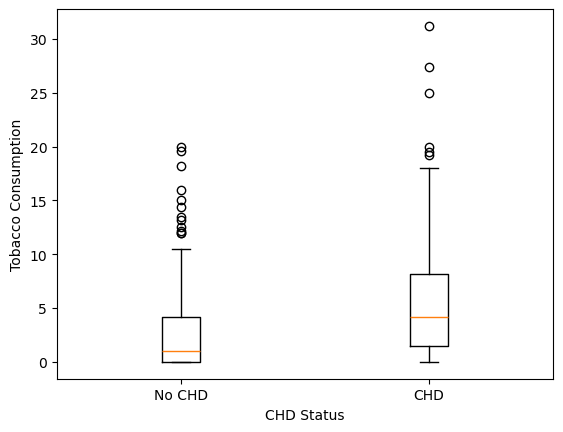

In [31]:
plt.boxplot([tobacco_no_chd, tobacco_chd], tick_labels=['No CHD', 'CHD'])
plt.xlabel('CHD Status')
plt.ylabel('Tobacco Consumption')
plt.show()

In [34]:
saheart_df[['sbp', 'obesity', 'age', 'ldl']].corr()

,sbp,obesity,age,ldl
sbp,1.000000,0.238067,0.388771,0.158296
obesity,0.238067,1.000000,0.291777,0.330506
age,0.388771,0.291777,1.000000,0.311799
ldl,0.158296,0.330506,0.311799,1.000000


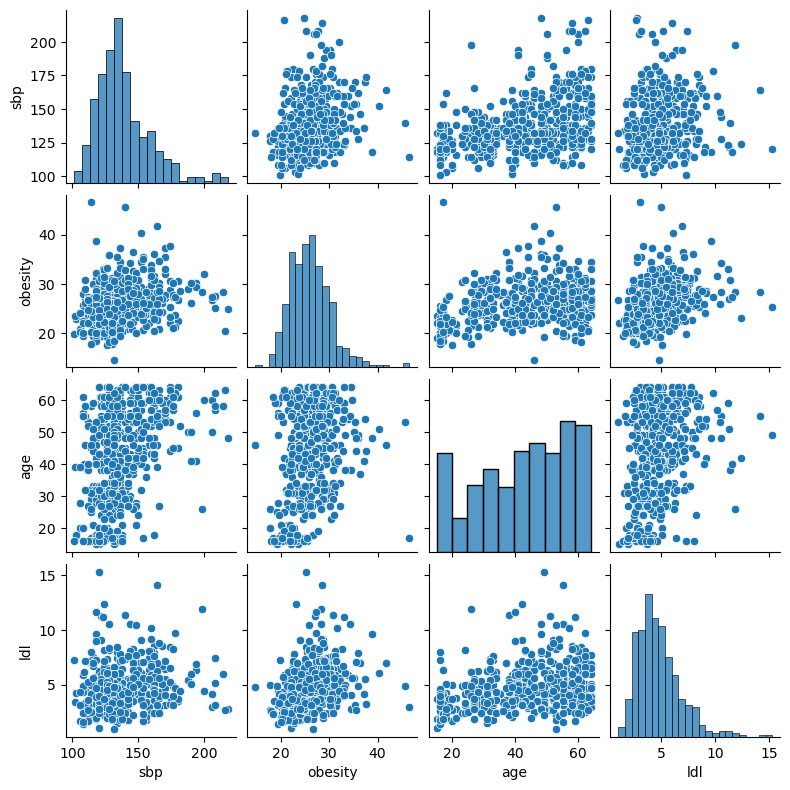

In [36]:
sn.pairplot(saheart_df[['sbp', 'obesity', 'age', 'ldl']], height=2)

<Axes: >

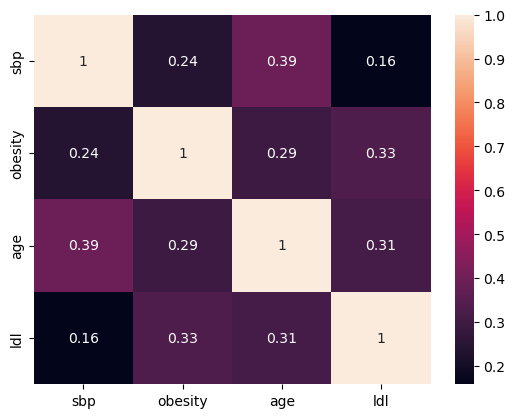

In [37]:
sn.heatmap(saheart_df[['sbp', 'obesity', 'age', 'ldl']].corr(), annot=True)

In [41]:
saheart_df['agegroup']=pd.cut(
    saheart_df['age'],
    bins=[0,15,35,55, 100],
    labels=['young', 'adults', 'mid', 'old'],
    right=False
)
saheart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   sbp        462 non-null    int64   
 1   tobacco    462 non-null    float64 
 2   ldl        462 non-null    float64 
 3   adiposity  462 non-null    float64 
 4   famhist    462 non-null    object  
 5   typea      462 non-null    int64   
 6   obesity    462 non-null    float64 
 7   alcohol    462 non-null    float64 
 8   age        462 non-null    int64   
 9   chd        462 non-null    object  
 10  agegroup   462 non-null    category
dtypes: category(1), float64(5), int64(3), object(2)
memory usage: 36.9+ KB


In [47]:
count3=pd.crosstab(saheart_df['agegroup'], saheart_df['chd'])
print(count3)

chd        No  Si
agegroup         
adults    125  18
mid       118  71
old        59  71


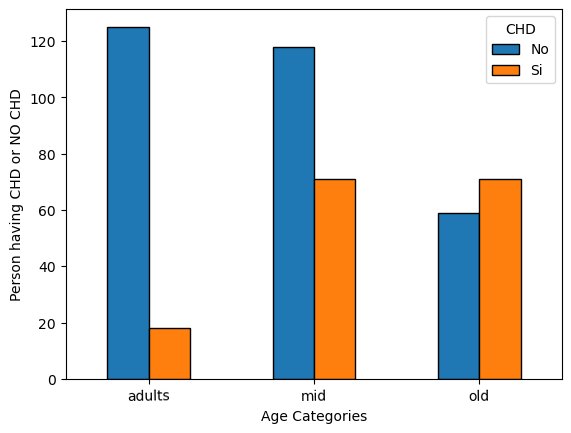

In [49]:
count3.plot(kind='bar', edgecolor='black', linewidth=1)
plt.xlabel('Age Categories')
plt.ylabel('Person having CHD or NO CHD')
plt.legend(title='CHD')
plt.xticks(rotation=True)
plt.show()

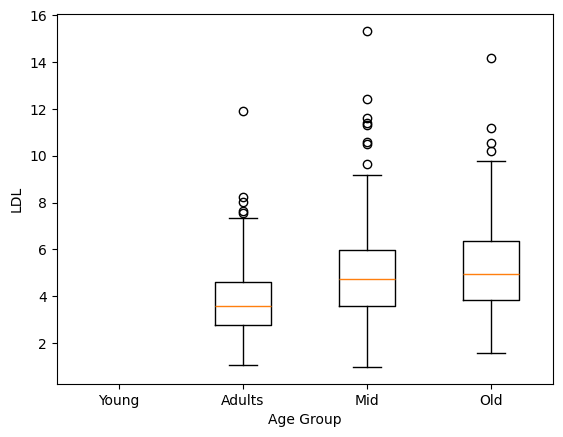

In [51]:
ldl_young=saheart_df[saheart_df['agegroup']=='young']['ldl']
ldl_adults=saheart_df[saheart_df['agegroup']=='adults']['ldl']
ldl_mid=saheart_df[saheart_df['agegroup']=='mid']['ldl']
ldl_old=saheart_df[saheart_df['agegroup']=='old']['ldl']
plt.figure()
plt.boxplot([ldl_young, ldl_adults, ldl_mid, ldl_old], 
            tick_labels=['Young', 'Adults', 'Mid', "Old"])
plt.xlabel('Age Group')
plt.ylabel('LDL')
plt.show()